# Final Task

In this assignment we will be looking to calculate and plot the solutions to the one-dimensional time-independent Schrodinger equation, stated below:

$$
-\frac{\hbar^2}{2m} \frac{d^2\psi}{dx^2} + V(x)\psi(x) = E\psi(x)
$$

Initially the code aims to calculate the solutions to the infinite square well. Inside the well, the the potential is equal to zero. Meanwhile outside the boundaries, the potentials shoots to infinity.


Firstly, I will need to define the mass & charge of an electron, as well as the reduced Planck's constants:

$$ m_{e} = 9.1094 \times 10^{-31} kg $$ 
$$ \hbar = 1.0546 \times 10^{-34} J.s $$ 
$$ Q_{e} = 1.6022 \times 10^{-19} C $$
 

In [2]:
#import the necessary modules
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline 

In [3]:
# establishing the key constants required for this task 
m = 9.1094e-31 #mass of electron in kilograms
hbar = 1.0546e-34 #reduced Planck's constant in Js-1
e = 1.6022e-19 #electron charge in C

#initial conditions for psi and phi
initialphi = 0.0
initialpsi = 1.0

### 1. Defining key functions to solve the infinite square well

I will begin by defining some of the key features of the infinite square well. This includes: 

- defining a function which will return 0 for the potential V(x) between -a ≤ x ≤ +a
- assigning the half-width of the well to be $ a = 5 \times 10^{-11} m$, so that $ 2a = 10^{-11}m$ 

In [4]:
def V(x): 
    '''This function will return a value of 0 to any value of x'''
    return 0.0 

a = 5e-11 #half-width of the potential well in metres

In [5]:
#setting conditions for the x-array
xstart = -a #initial value of the x array
xend = +a #final value of the x array
N = 1000 #number of terms in the x array
h = (xend - xstart) / N

psi = 0.0
phi = 1.0

The Schrodinger equation has already been split up into two first order equations:

$$ \frac{d \psi}{dx } = \phi $$ 
$$ \frac{d \phi}{dx } = \frac{2m}{\hbar^2} \left[V(x) - E \right] \psi(x)  $$

Below I have defined another function to calculate the right hand side of the first order equations.

In [6]:
def f(r, x, E):
    '''This functions outputs the RHS of the second and third equation for
    Inputs:
    -2D array of psi and phi
    -2D of array r
    -array of position values, x
    -Energy, E
    Outputs:
    -derivative of psi with respect to x
    -derivative of phi with respect to x'''
    
    psi = r[0] #first component of vector r
    phi = r[1] #second component
    
    d_psi = phi #derivative of psi
    d_phi = (2*m)/(hbar**2) * (V(x)-E)*psi #derivative of phi 
    
    return np.array([d_psi, d_phi]) #returns a 2-dimensional array of the derivaties of psi and phi

### Ranga Kutta function

Now we need to use a fourth-order Ranga Kutta function and create an array of x values of with a step size $h = 2a/N$. The Ranga Kutta function will return an array of the wavefunction values representing $\psi(x) $.




In [7]:
#creating the x-array 
xpoints = np.arange(xstart, xend, h)


#creating the fourth-orderRunge Kutta 
def RungeKutta2d(xpoints, E):
    '''Fourth-order Runge-Kutta rewritten for two simultaneous equations
    Inputs: first component is x value
            second component is the energy, E
    Outputs [psipoints]: solutions for psi(x), numpy arrays one longer than xpoints'''
    
    r = np.array([initialphi, initialpsi])
    psipoints = [] # initialise empty arrays
    phipoints = []
    
    for x in xpoints: # loops over all tpoints up to (tend-h)
        psipoints.append(r[0])
        phipoints.append(r[1])
       
        k1 = h*f(r, x, E) 
        k2 = h*f(r+0.5*k1, x+0.5*h, E)
        k3 = h*f(r+0.5*k2, x+0.5*h, E)
        k4 = h*f(r+k3, x+h, E)
        r = r + (k1 + 2*k2 + 2*k3 + k4)/6
        
    # these next two lines calculate for the point at x = xend
    psipoints.append(r[0])
    phipoints.append(r[1])
    
    return np.array([psipoints]) # convert output to numpy array with only psi, since we don't need to return an array to represent phi

### 2. Finding the ground state energy

In [8]:
E1 = 0  # guess 1 of initial E (J)
E2 = e  # guess 2 of initial E (J)

####### Solve for the first guess:
soln1 = RungeKutta2d(xpoints, E1) # the whole array of solutions for E1
wavefunction1 = soln1[0,N]            # final element is at index N (counting from zero)

print(wavefunction1)

####### solve for the second guess:
soln2 = RungeKutta2d(xpoints, E2) # the whole array of solutions for E1
wavefunction2 = soln2[0,N]        # final element is at index N (counting from zero)


print(wavefunction2)

### now for the secant method to converge on the right answer
tolerance = e/1000 # set the tolerance
err = 1 # initialise the error variable
while err > tolerance:
    E3 = E2 - wavefunction2*(E2-E1)/(wavefunction2-wavefunction1)
    err = abs(E2-E1) 
    # reset initial energies for the next iteration
    E1 = E2 
    E2 = E3 
    # and recalculate heights
    soln1 = RungeKutta2d(xpoints, E1) # the whole array of solutions for E1
    soln2 = RungeKutta2d(xpoints, E2) # the whole array of solutions for E1

    wavefunction1 = soln1[0,N]
    wavefunction2 = soln2[0,N]
    
print("The ground state energy in an infinite square well is equal to", E3/e, "eV")

1e-10
9.56827348423e-11
The ground state energy in an infinite square well is equal to 37.6044103908 eV


Now let's compare this to the known ground state energy, by recalling the eigenbalues of this system using:

$$
E_n = \frac{\pi^2 \hbar^2 n^2}{2m (2a)^2}
$$

In [9]:
E1_known = ((np.pi * hbar )**2) / (2*m*((2*a))**2) #code for the equation above

print ("The known ground state energy is", E1_known/e," eV")

print ("The difference between our estimated value and the known value is", (E3-E1_known)/e, "eV")

The known ground state energy is 37.60441039077787  eV
The difference between our estimated value and the known value is 6.10595040913e-11 eV


### 3. Finding the ground state wavefunction



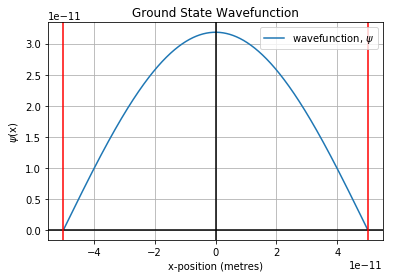

In [10]:
xplotpoints = np.arange(xstart, xend+h, h) #an array similar to xpoints, but this includes the end point

soln3 = RungeKutta2d(xpoints,E3) #the solution with the closest value to the roots

plt.grid()
plt.plot(xplotpoints, soln3[0], label = "wavefunction, $\psi$") #wavefunction
plt.axvline(x=0, c='k', ls='-') #y-axis
plt.axhline(y=0, c='k', ls='-') #y-axis


plt.legend(loc="best")
plt.title('Ground State Wavefunction')
plt.xlabel("x-position (metres)") 
plt.ylabel("$\psi$(x)")
plt.legend(loc="best")

#plotting infinite walls at at +a and -a
plt.axvline(x=-a, c='r', ls='-') 
plt.axvline(x=+a, c='r', ls='-')

Our wavefunction as calculated is not normalised. We need to write a new function that will normalise the wavefunction, so that:

$$
\int | \psi(x) |^2 {\rm d} x = 1
$$

To do this, I will calculate the LHS of the above equation using the trapezoidal rule:

$$
I(a,b) = h \left[ \frac{1}{2}f(a) + \frac{1}{2}f(b) +
      \sum_{k=1}^{n-1}f(x + kh) \right]
$$

In [11]:
#coding for the trapezoidal rule:
I = h * ( (0.5*soln3[0,0])**2 + (0.5*soln3[0,1000])**2 + ((np.sum(soln3[0]**2) - soln3[0,0]**2 - soln3[0,1000]**2)))

print ("the value of the integral =", I )

the value of the integral = 5.06605918211e-32


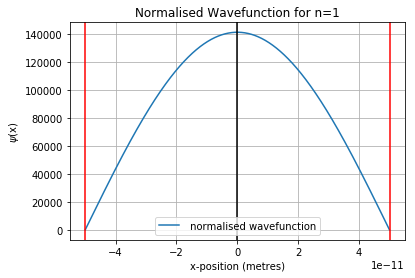

In [11]:
plt.plot(xplotpoints,(soln3[0]/ np.sqrt(I)), label=" normalised wavefunction") #plots normalised wavefunction
plt.axvline(x=0,c='k',ls='-') 
plt.legend(loc="best") #place legend in best location
plt.grid(b=True, which='both', color='0.69',ls='-') #plot grey gridlines on the graph
plt.xlabel("x-position (metres)") 
plt.ylabel("$\psi$(x)")
plt.title("Normalised Wavefunction for n=1") 

plt.axvline(x=-a,c='r', ls='-') 
plt.axvline(x=a,c='r',ls='-') 



Next, I checked how the calculated wavefunction compared to the known ground state function, given below:

$$
\psi_n(x)  = \frac{1}{\sqrt{a}} \cos\left(\frac{ n \pi x}{2a}\right) \qquad 
    n \ \mathrm{odd}
    $$
    $$
    \psi_n(x)  = \frac{1}{\sqrt{a}} \sin\left(\frac{ n \pi x}{2a}\right) \qquad
    n \ \mathrm{even}.
$$

To do so, I created a new function below which assigns the correct normalised values, depending on whether the wavefunctions are odd or even.

In [12]:
def norm_function(x,n):
    '''a function which outputs the normalised values of the wavefunction, 
    input: n'''
    if n%2==0: #when the integer is divided by two, it uses the remainder to determine whether it is even or odd
        norm_values=((np.sin((n * np.pi * x)/(2.0*a)))/ (np.sqrt(a)) ) #when there is no remainder; it is even
    else: 
        norm_values=((np.cos((n * np.pi * x)/(2.0*a)))/ (np.sqrt(a)) ) #when there is a remainder; it is odd
        
    return norm_values

[  8.65956056e-12   4.44287563e+02   8.88570741e+02 ...,   8.88570741e+02
   4.44287563e+02   7.29388857e-09]


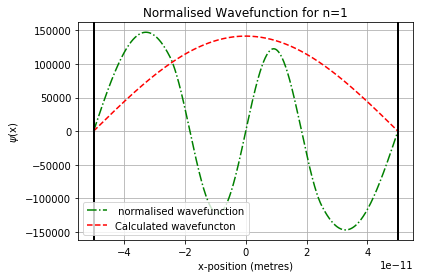

In [83]:
print(norm_function(xplotpoints,1))

plt.grid()
plt.plot(xplotpoints,(soln3[0]/ np.sqrt(I)), 'g-.', label=" normalised wavefunction") #plots normalised wavefunction
plt.plot(xplotpoints,norm_function(xplotpoints,1),'r--', label='Calculated wavefuncton') # plots known wavefunction for n=1
plt.xlabel("x-position (metres)") 
plt.ylabel("$\psi$(x)")
plt.title("Normalised Wavefunction for n=1") 
plt.legend(loc = 'best')

plt.axvline(x=-a, c='k', ls='-', lw=2)
plt.axvline(x=a, c='k', ls='-', lw=2)

As we can see, there is a perfect match between my numerical results and the analytical solutions.

### 4. Finding the wavefunction for the n=2, n=3, n=4 and n=20 states

#### a) n=2

Firstly, we need to calculate the energy for the second level, as this will allow us to make appropriate guesses for the secant method. Again, the equation used has been listed below:

$$
E_n = \frac{\pi^2 \hbar^2 n^2}{2m (2a)^2}
$$

In [14]:
#known energy for n=20
level=2
E2_known = ((np.pi * hbar * level )**2) / (2*m*((2*a))**2)

print  ("The known ground state energy is", E2_known/e," eV")

('The known ground state energy is', 150.4176415631115, ' eV')


In [15]:
E1 = 100*e                        # guess 1 of initial E (J)
E2 = 200*e                     # guess 2 of initial E (J)

####### Solve for the first guess:
soln1 = RungeKutta2d(xpoints, E1) # the whole array of solutions for E1
est1 = soln1[0,N]            # final element is at index N (counting from zero)

####### solve for the second guess:
soln2 = RungeKutta2d(xpoints, E2) # the whole array of solutions for E1
est2 = soln2[0,N]        # final element is at index N (counting from zero)

### now for the secant method to converge on the right answer
tolerance = e/1000 # set the tolerance
err = 1 # initialise the error variable
while err > tolerance:
    E3 = E2 - est2*(E2-E1)/(est2-est1)
    err = abs(E2-E1) 
    # reset initial energies for the next iteration
    E1 = E2 
    E2 = E3 
    # and recalculate heights
    soln1 = RungeKutta2d(xpoints, E1) # the whole array of solutions for E1
    soln2 = RungeKutta2d(xpoints, E2) # the whole array of solutions for E1

    est1 = soln1[0,N]
    est2 = soln2[0,N]
    
print("The ground state energy in an infinite square well is equal to", E3/e, "eV")

('The ground state energy in an infinite square well is equal to', 150.41764156701868, 'eV')


The associated normalised wavefunction has been calculated below:

In [16]:
#coding for the trapezoidal rule:
I = h * ( (0.5*soln3[0,0])**2 + (0.5*soln3[0,1000])**2 + ((np.sum(soln3[0]**2) - soln3[0,0]**2 - soln3[0,1000]**2))  )

print ("the value of the integral =", I )

('the value of the integral =', 5.0660591821086311e-32)


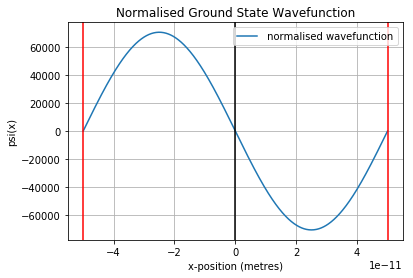

In [17]:
xplotpoints = np.arange(xstart, xend+h, h) #an array similar to xpoints, but this includes the end point


soln3 = RungeKutta2d(xpoints,E3) #the solution with the closest value to the roots



plt.plot(xplotpoints,(soln3[0]/ np.sqrt(I)), label=" normalised wavefunction") #plots normalised wavefunction
plt.axvline(x=0,c='k',ls='-') 
plt.legend(loc="best") #place legend in best location
plt.grid(b=True, which='both', color='0.69',ls='-') #plot grey gridlines on the graph
plt.xlabel("x-position (metres)") 
plt.ylabel("psi(x)")
plt.title("Normalised Ground State Wavefunction") 

plt.axvline(x=-a,c='r', ls='-') 
plt.axvline(x=a,c='r',ls='-') 



In [18]:
def norm_function(x,n):
    '''a function which outputs the normalised values of the wavefunction, 
    input: n'''
    if n%2==0: #when the integer is divided by two, it uses the remainder to determine whether it is even or odd
        norm_values=((np.sin((n * np.pi * x)/(2.0*a)))/ (np.sqrt(a)) ) #when there is no remainder; it is even
    else: 
        norm_values=((np.cos((n * np.pi * x)/(2.0*a)))/ (np.sqrt(a)) ) #when there is a remainder; it is odd
        
    return norm_values

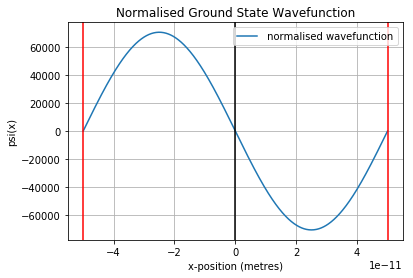

In [19]:
plt.plot(xplotpoints,(soln3[0]/ np.sqrt(I)), label=" normalised wavefunction") #plots normalised wavefunction
plt.axvline(x=0,c='k',ls='-') 
plt.legend(loc="best") #place legend in best location
plt.grid() #plot grey gridlines on the graph
plt.xlabel("x-position (metres)") 
plt.ylabel("psi(x)")
plt.title("Normalised Ground State Wavefunction") 

plt.axvline(x=-a,c='r', ls='-') 
plt.axvline(x=a,c='r',ls='-') 



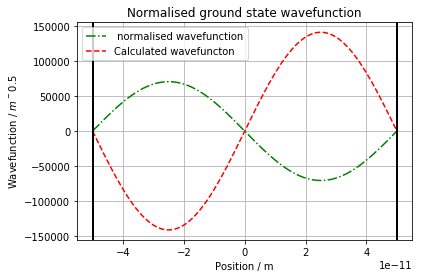

In [20]:
plt.grid()
plt.plot(xplotpoints, (soln3[0]/ np.sqrt(I)), 'g-.', label=" normalised wavefunction") #plots normalised wavefunction
plt.plot(xplotpoints, norm_function(xplotpoints, level),'r--', label='Calculated wavefuncton') # plots known wavefunction for n=1
plt.xlabel('Position / m')
plt.ylabel('Wavefunction / $m^-0.5$')
plt.title('Normalised ground state wavefunction')
plt.legend(loc = 'best')

plt.axvline(x=-a, c='k', ls='-', lw=2)
plt.axvline(x=a, c='k', ls='-', lw=2)

#### a) n=3

Firstly, we need to calculate the energy for the second level, as this will allow us to make appropriate guesses for the secant method. Again, the equation used has been listed below:

$$
E_n = \frac{\pi^2 \hbar^2 n^2}{2m (2a)^2}
$$

In [21]:
#known energy for n=3
level=3
E_known = ((np.pi * hbar * level )**2) / (2*m*((2*a))**2)

print  ("The known ground state energy is", E_known/e," eV")

('The known ground state energy is', 338.4396935170008, ' eV')


In [22]:
E1 = 300*e                        # guess 1 of initial E (J)
E2 = 350*e                     # guess 2 of initial E (J)

####### Solve for the first guess:
soln1 = RungeKutta2d(xpoints, E1) # the whole array of solutions for E1
est1 = soln1[0,N]            # final element is at index N (counting from zero)

####### solve for the second guess:
soln2 = RungeKutta2d(xpoints, E2) # the whole array of solutions for E1
est2 = soln2[0,N]        # final element is at index N (counting from zero)

### now for the secant method to converge on the right answer
tolerance = e/1000 # set the tolerance
err = 1 # initialise the error variable
while err > tolerance:
    E3 = E2 - est2*(E2-E1)/(est2-est1)
    err = abs(E2-E1) 
    # reset initial energies for the next iteration
    E1 = E2 
    E2 = E3 
    # and recalculate heights
    soln1 = RungeKutta2d(xpoints, E1) # the whole array of solutions for E1
    soln2 = RungeKutta2d(xpoints, E2) # the whole array of solutions for E1

    est1 = soln1[0,N]
    est2 = soln2[0,N]
    
print("The ground state energy in an infinite square well is equal to", E3/e, "eV")

('The ground state energy in an infinite square well is equal to', 338.43969356150524, 'eV')


The associated wavefunction has been calculated below:

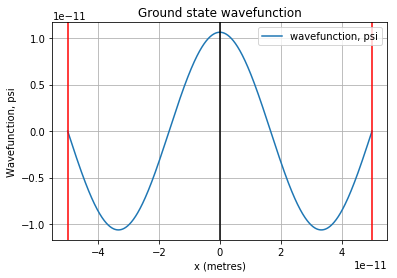

In [23]:
xplotpoints = np.arange(xstart, xend+h, h) #an array similar to xpoints, but this includes the end point

soln3 = RungeKutta2d(xpoints,E3) #the solution with the closest value to the roots

plt.grid()
plt.plot(xplotpoints, -soln3[0], label = "wavefunction, psi") #wavefunction
plt.axvline(x=0, c='k', ls='-') #y-axis


plt.legend(loc="best")
plt.title('Ground state wavefunction')
plt.xlabel('x (metres)')
plt.ylabel('Wavefunction, psi')
plt.legend(loc="best")

#plotting infinite walls at at +a and -a
plt.axvline(x=-a, c='r', ls='-') 
plt.axvline(x=+a, c='r', ls='-')

In [24]:
#coding for the trapezoidal rule:
I = h * ( (0.5*soln3[0,0])**2 + (0.5*soln3[0,1000])**2 + ((np.sum(soln3[0]**2) - soln3[0,0]**2 - soln3[0,1000]**2))  )

print ("the value of the integral =", I )

('the value of the integral =', 5.6289546460289558e-33)


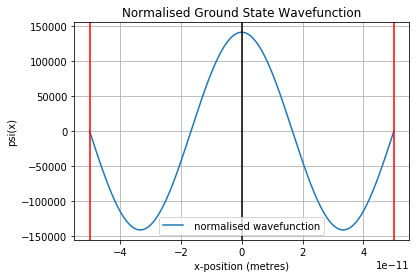

In [25]:
plt.plot(xplotpoints,(-soln3[0]/ np.sqrt(I)), label=" normalised wavefunction") #plots normalised wavefunction
plt.axvline(x=0,c='k',ls='-') 
plt.legend(loc="best") #place legend in best location
plt.grid(b=True, which='both', color='0.69',ls='-') #plot grey gridlines on the graph
plt.xlabel("x-position (metres)") 
plt.ylabel("psi(x)")
plt.title("Normalised Ground State Wavefunction") 

plt.axvline(x=-a,c='r', ls='-') 
plt.axvline(x=a,c='r',ls='-') 



In [26]:
def norm_function(x,n):
    '''a function which outputs the normalised values of the wavefunction, 
    input: n'''
    if n%2==0: #when the integer is divided by two, it uses the remainder to determine whether it is even or odd
        norm_values=((np.sin((n * np.pi * x)/(2.0*a)))/ (np.sqrt(a)) ) #when there is no remainder; it is even
    else: 
        norm_values=((np.cos((n * np.pi * x)/(2.0*a)))/ (np.sqrt(a)) ) #when there is a remainder; it is odd
        
    return norm_values

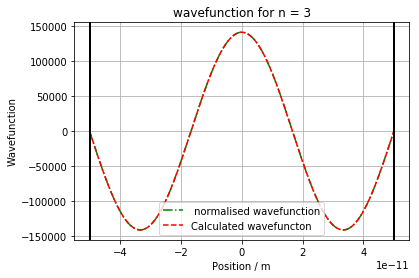

In [27]:
plt.grid()
plt.plot(xplotpoints, -(soln3[0]/ np.sqrt(I)), 'g-.', label=" normalised wavefunction") #plots normalised wavefunction
plt.plot(xplotpoints,norm_function(xplotpoints, level),'r--', label='Calculated wavefuncton') # plots known wavefunction for n=1
plt.xlabel('Position / m')
plt.ylabel('Wavefunction')
plt.title('wavefunction for n = 3')
plt.legend(loc = 'best')

plt.axvline(x=-a, c='k', ls='-', lw=2)
plt.axvline(x=a, c='k', ls='-', lw=2)

#### a) n=4

Firstly, we need to calculate the energy for the second level, as this will allow us to make appropriate guesses for the secant method. Again, the equation used has been listed below:

$$
E_n = \frac{\pi^2 \hbar^2 n^2}{2m (2a)^2}
$$

In [28]:
#known energy for n=4
level=4
E2_known = ((np.pi * hbar * level )**2) / (2*m*((2*a))**2)

print  ("The known ground state energy is", E2_known/e," eV")

('The known ground state energy is', 601.670566252446, ' eV')


In [29]:
E1 = 550*e                        # guess 1 of initial E (J)
E2 = 650*e                     # guess 2 of initial E (J)

####### Solve for the first guess:
soln1 = RungeKutta2d(xpoints, E1) # the whole array of solutions for E1
est1 = soln1[0,N]            # final element is at index N (counting from zero)

####### solve for the second guess:
soln2 = RungeKutta2d(xpoints, E2) # the whole array of solutions for E1
est2 = soln2[0,N]        # final element is at index N (counting from zero)

### now for the secant method to converge on the right answer
tolerance = e/1000 # set the tolerance
err = 1 # initialise the error variable
while err > tolerance:
    E3 = E2 - est2*(E2-E1)/(est2-est1)
    err = abs(E2-E1) 
    # reset initial energies for the next iteration
    E1 = E2 
    E2 = E3 
    # and recalculate heights
    soln1 = RungeKutta2d(xpoints, E1) # the whole array of solutions for E1
    soln2 = RungeKutta2d(xpoints, E2) # the whole array of solutions for E1

    est1 = soln1[0,N]
    est2 = soln2[0,N]
    
print("The ground state energy in an infinite square well is equal to", E3/e, "eV")

N4_energy = E3/e

('The ground state energy in an infinite square well is equal to', 601.67056650249367, 'eV')


The associated wavefunction has been calculated below:

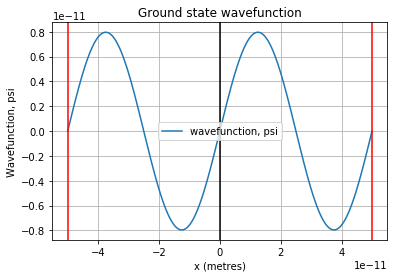

In [30]:
xplotpoints = np.arange(xstart, xend+h, h) #an array similar to xpoints, but this includes the end point

soln3 = RungeKutta2d(xpoints,E3) #the solution with the closest value to the roots

plt.grid()
plt.plot(xplotpoints, soln3[0], label = "wavefunction, psi") #wavefunction
plt.axvline(x=0, c='k', ls='-') #y-axis


plt.legend(loc="best")
plt.title('Ground state wavefunction')
plt.xlabel('x (metres)')
plt.ylabel('Wavefunction, psi')
plt.legend(loc="best")

#plotting infinite walls at at +a and -a
plt.axvline(x=-a, c='r', ls='-') 
plt.axvline(x=+a, c='r', ls='-')

In [31]:
#coding for the trapezoidal rule:
I = h * ( (0.5*soln3[0,0])**2 + (0.5*soln3[0,1000])**2 + ((np.sum(soln3[0]**2) - soln3[0,0]**2 - soln3[0,1000]**2))  )

print ("the value of the integral =", I )

('the value of the integral =', 3.1662869874205973e-33)


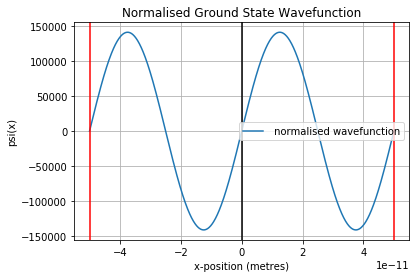

In [32]:
plt.plot(xplotpoints,(soln3[0]/ np.sqrt(I)), label=" normalised wavefunction") #plots normalised wavefunction
plt.axvline(x=0,c='k',ls='-') 
plt.legend(loc="best") #place legend in best location
plt.grid(b=True, which='both', color='0.69',ls='-') #plot grey gridlines on the graph
plt.xlabel("x-position (metres)") 
plt.ylabel("psi(x)")
plt.title("Normalised Ground State Wavefunction") 

plt.axvline(x=-a,c='r', ls='-') 
plt.axvline(x=a,c='r',ls='-') 



In [33]:
def norm_function(x,n):
    '''a function which outputs the normalised values of the wavefunction, 
    input: n'''
    if n%2==0: #when the integer is divided by two, it uses the remainder to determine whether it is even or odd
        norm_values=((np.sin((n * np.pi * x)/(2.0*a)))/ (np.sqrt(a)) ) #when there is no remainder; it is even
    else: 
        norm_values=((np.cos((n * np.pi * x)/(2.0*a)))/ (np.sqrt(a)) ) #when there is a remainder; it is odd
        
    return norm_values

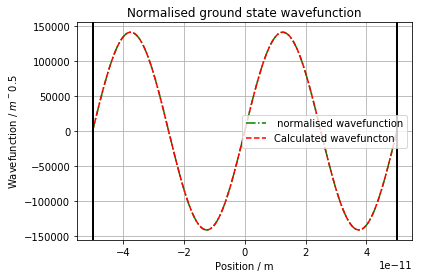

In [34]:
plt.grid()
plt.plot(xplotpoints, (soln3[0]/ np.sqrt(I)), 'g-.', label=" normalised wavefunction") #plots normalised wavefunction
plt.plot(xplotpoints,norm_function(xplotpoints, level),'r--', label='Calculated wavefuncton') # plots known wavefunction for n=1
plt.xlabel('Position / m')
plt.ylabel('Wavefunction / $m^-0.5$')
plt.title('Normalised ground state wavefunction')
plt.legend(loc = 'best')

plt.axvline(x=-a, c='k', ls='-', lw=2)
plt.axvline(x=a, c='k', ls='-', lw=2)

#### a) n=20

Firstly, we need to calculate the energy for the second level, as this will allow us to make appropriate guesses for the secant method. Again, the equation used has been listed below:

$$
E_n = \frac{\pi^2 \hbar^2 n^2}{2m (2a)^2}
$$

In [35]:
#known energy for n=20
level=20
E2_known = ((np.pi * hbar * level )**2) / (2*m*((2*a))**2)

print  ("The known ground state energy is", E2_known/e," eV")

('The known ground state energy is', 15041.764156311152, ' eV')


In [36]:
E1 = 14950*e                        # guess 1 of initial E (J)
E2 = 15050*e                     # guess 2 of initial E (J)

####### Solve for the first guess:
soln1 = RungeKutta2d(xpoints, E1) # the whole array of solutions for E1
est1 = soln1[0,N]            # final element is at index N (counting from zero)

####### solve for the second guess:
soln2 = RungeKutta2d(xpoints, E2) # the whole array of solutions for E1
est2 = soln2[0,N]        # final element is at index N (counting from zero)

### now for the secant method to converge on the right answer
tolerance = e/1000 # set the tolerance
err = 1 # initialise the error variable
while err > tolerance:
    E3 = E2 - est2*(E2-E1)/(est2-est1)
    err = abs(E2-E1) 
    # reset initial energies for the next iteration
    E1 = E2 
    E2 = E3 
    # and recalculate heights
    soln1 = RungeKutta2d(xpoints, E1) # the whole array of solutions for E1
    soln2 = RungeKutta2d(xpoints, E2) # the whole array of solutions for E1

    est1 = soln1[0,N]
    est2 = soln2[0,N]
    
print("The ground state energy in an infinite square well is equal to", E3/e, "eV")

('The ground state energy in an infinite square well is equal to', 15041.768058018595, 'eV')


The associated wavefunction has been calculated below:

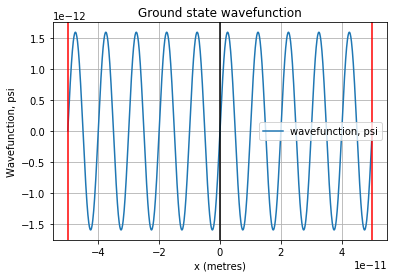

In [37]:
xplotpoints = np.arange(xstart, xend+h, h) #an array similar to xpoints, but this includes the end point

soln3 = RungeKutta2d(xpoints,E3) #the solution with the closest value to the roots

plt.grid()
plt.plot(xplotpoints, soln3[0], label = "wavefunction, psi") #wavefunction
plt.axvline(x=0, c='k', ls='-') #y-axis


plt.legend(loc="best")
plt.title('Ground state wavefunction')
plt.xlabel('x (metres)')
plt.ylabel('Wavefunction, psi')
plt.legend(loc="best")

#plotting infinite walls at at +a and -a
plt.axvline(x=-a, c='r', ls='-') 
plt.axvline(x=+a, c='r', ls='-')

In [38]:
#coding for the trapezoidal rule:
I = h * ( (0.5*soln3[0,0])**2 + (0.5*soln3[0,1000])**2 + ((np.sum(soln3[0]**2) - soln3[0,0]**2 - soln3[0,1000]**2))  )

print ("the value of the integral =", I )

('the value of the integral =', 1.2665139261113027e-34)


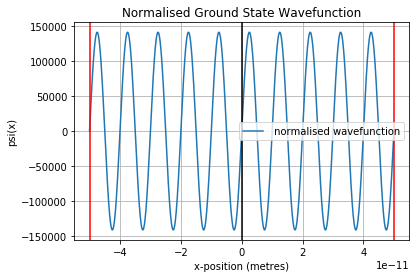

In [39]:
plt.plot(xplotpoints,(soln3[0]/ np.sqrt(I)), label=" normalised wavefunction") #plots normalised wavefunction
plt.axvline(x=0,c='k',ls='-') 
plt.legend(loc="best") #place legend in best location
plt.grid(b=True, which='both', color='0.69',ls='-') #plot grey gridlines on the graph
plt.xlabel("x-position (metres)") 
plt.ylabel("psi(x)")
plt.title("Normalised Ground State Wavefunction") 

plt.axvline(x=-a,c='r', ls='-') 
plt.axvline(x=a,c='r',ls='-') 



In [40]:
def norm_function(x,n):
    '''a function which outputs the normalised values of the wavefunction, 
    input: n'''
    if n%2==0: #when the integer is divided by two, it uses the remainder to determine whether it is even or odd
        norm_values=((np.sin((n * np.pi * x)/(2.0*a)))/ (np.sqrt(a)) ) #when there is no remainder; it is even
    else: 
        norm_values=((np.cos((n * np.pi * x)/(2.0*a)))/ (np.sqrt(a)) ) #when there is a remainder; it is odd
        
    return norm_values

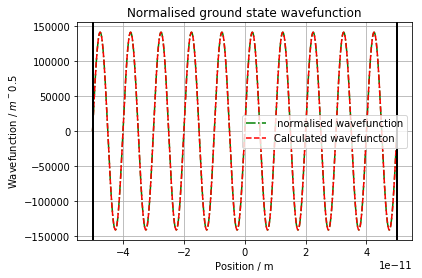

In [41]:
plt.grid()
plt.plot(xplotpoints, (soln3[0]/ np.sqrt(I)), 'g-.', label=" normalised wavefunction") #plots normalised wavefunction
plt.plot(xplotpoints,norm_function(xplotpoints, level),'r--', label='Calculated wavefuncton') # plots known wavefunction for n=1
plt.xlabel('Position / m')
plt.ylabel('Wavefunction / $m^-0.5$')
plt.title('Normalised ground state wavefunction')
plt.legend(loc = 'best')

plt.axvline(x=-a, c='k', ls='-', lw=2)
plt.axvline(x=a, c='k', ls='-', lw=2)

### 5. Infinite unsquare well

I will no extend these calculations for systems where the base of the potential well is no longer equal to zero.

In the first situation, we will be looking at the Harmonic potential:


$$
V(x) = V_0 \frac{x^2}{a^2}
$$

To begin with, we will need to create a function to code for this Harmonic potential:

In [42]:
V0 = 800*e

def V(x): 
    '''This function will return the harmonic potential of a particle
    input: 
    - position x
    - boundary a'''
    Vharm = V0 * (x**2 / a**2)
    return Vharm 


In [43]:
E1 = 0                        # guess 1 of initial E (J)
E2 = e                     # guess 2 of initial E (J)

####### Solve for the first guess:
soln1 = RungeKutta2d(xpoints, E1) # the whole array of solutions for E1
wavefunction1 = soln1[0,N]            # final element is at index N (counting from zero)

####### solve for the second guess:
soln2 = RungeKutta2d(xpoints, E2) # the whole array of solutions for E1
wavefunction2 = soln2[0,N]        # final element is at index N (counting from zero)

### now for the secant method to converge on the right answer
tolerance = e/1000 # set the tolerance
err = 1 # initialise the error variable
while err > tolerance:
    E3 = E2 - wavefunction2*(E2-E1)/(wavefunction2-wavefunction1)
    err = abs(E2-E1) 
    # reset initial energies for the next iteration
    E1 = E2 
    E2 = E3 
    # and recalculate heights
    soln1 = RungeKutta2d(xpoints, E1) # the whole array of solutions for E1
    soln2 = RungeKutta2d(xpoints, E2) # the whole array of solutions for E1

    wavefunction1 = soln1[0,N]
    wavefunction2 = soln2[0,N]
    
print("The ground state energy in an infinite square well is equal to", E3/e, "eV")

N1_energy = E3/e

('The ground state energy in an infinite square well is equal to', 110.8596106221941, 'eV')


### 3. Finding the ground state wavefunction



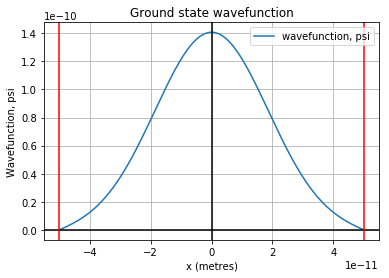

In [44]:
xplotpoints = np.arange(xstart, xend+h, h) #an array similar to xpoints, but this includes the end point

soln3 = RungeKutta2d(xpoints,E3) #the solution with the closest value to the roots

plt.grid()
plt.plot(xplotpoints, soln3[0], label = "wavefunction, psi") #wavefunction
plt.axvline(x=0, c='k', ls='-') #y-axis
plt.axhline(y=0, c='k', ls='-')


plt.legend(loc="best")
plt.title('Ground state wavefunction')
plt.xlabel('x (metres)')
plt.ylabel('Wavefunction, psi')
plt.legend(loc="best")

#plotting infinite walls at at +a and -a
plt.axvline(x=-a, c='r', ls='-') 
plt.axvline(x=+a, c='r', ls='-')


Our wavefunction as calculated is not normalised. We need to write a new function that will normalise the wavefunction, so that:

$$
\int | \psi(x) |^2 {\rm d} x = 1
$$

To do this, I will calculate the LHS of the above equation using the trapezoidal rule:

$$
I(a,b) = h \left[ \frac{1}{2}f(a) + \frac{1}{2}f(b) +
      \sum_{k=1}^{n-1}f(x + kh) \right]
$$

In [45]:
#coding for the trapezoidal rule:
I = h * ( (0.5*soln3[0,0])**2 + (0.5*soln3[0,1000])**2 + ((np.sum(soln3[0]**2) - soln3[0,0]**2 - soln3[0,1000]**2))  )

print ("the value of the integral =", I )

('the value of the integral =', 6.4906757863403823e-31)


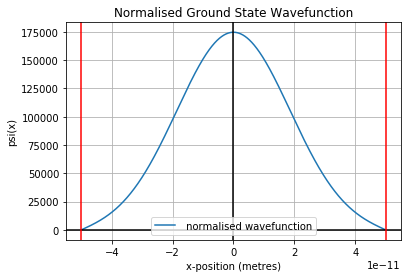

In [46]:
plt.plot(xplotpoints,(soln3[0]/ np.sqrt(I)), label=" normalised wavefunction") #plots normalised wavefunction
plt.axvline(x=0,c='k',ls='-') 
plt.axhline(y=0, c='k', ls='-')


plt.legend(loc="best") #place legend in best location
plt.grid(b=True, which='both', color='0.69',ls='-') #plot grey gridlines on the graph
plt.xlabel("x-position (metres)") 
plt.ylabel("psi(x)")
plt.title("Normalised Ground State Wavefunction") 

plt.axvline(x=-a,c='r', ls='-') 
plt.axvline(x=a,c='r',ls='-') 



Next, I checked how the calculated wavefunction compares to the known ground state function, given below:

$$
\psi_n(x)  = \frac{1}{\sqrt{a}} \cos\left(\frac{ n \pi x}{2a}\right) \qquad 
    n \ \mathrm{odd}
    $$
    $$
    \psi_n(x)  = \frac{1}{\sqrt{a}} \sin\left(\frac{ n \pi x}{2a}\right) \qquad
    n \ \mathrm{even}.
$$

In [47]:
def norm_function(x,n):
    '''a function which outputs the normalised values of the wavefunction, 
    input: n'''
    if n%2==0: #when the integer is divided by two, it uses the remainder to determine whether it is even or odd
        norm_values=((np.sin((n * np.pi * x)/(2.0*a)))/ (np.sqrt(a)) ) #when there is no remainder; it is even
    else: 
        norm_values=((np.cos((n * np.pi * x)/(2.0*a)))/ (np.sqrt(a)) ) #when there is a remainder; it is odd
        
    return norm_values

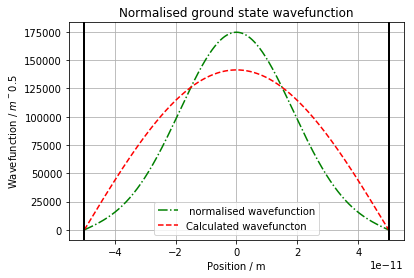

In [48]:
plt.grid()
plt.plot(xplotpoints,(soln3[0]/ np.sqrt(I)), 'g-.', label=" normalised wavefunction") #plots normalised wavefunction
plt.plot(xplotpoints,norm_function(xplotpoints,1),'r--', label='Calculated wavefuncton') # plots known wavefunction for n=1
plt.xlabel('Position / m')
plt.ylabel('Wavefunction / $m^-0.5$')
plt.title('Normalised ground state wavefunction')
plt.legend(loc = 'best')

plt.axvline(x=-a, c='k', ls='-', lw=2)
plt.axvline(x=a, c='k', ls='-', lw=2)

#### n = 2, n=3, n=4 

Now we will calculate similar wavefunctions for n=2, n=3 and n=4 

In [49]:
#known energy for n=20
level=2
E2_known = ((np.pi * hbar * level )**2) / (2*m*((2*a))**2)

print  ("The known ground state energy is", E2_known/e," eV")

('The known ground state energy is', 150.4176415631115, ' eV')


In [50]:
E1 = 155*e     #the first guess has to be higher than the first eigenvalue
E2 = 400*e                     # guess 2 of initial E (J)

####### Solve for the first guess:
soln1 = RungeKutta2d(xpoints, E1) # the whole array of solutions for E1
est1 = soln1[0,N]            # final element is at index N (counting from zero)

####### solve for the second guess:
soln2 = RungeKutta2d(xpoints, E2) # the whole array of solutions for E1
est2 = soln2[0,N]        # final element is at index N (counting from zero)

### now for the secant method to converge on the right answer
tolerance = e/1000 # set the tolerance
err = 1 # initialise the error variable
while err > tolerance:
    E3 = E2 - est2*(E2-E1)/(est2-est1)
    err = abs(E2-E1) 
    # reset initial energies for the next iteration
    E1 = E2 
    E2 = E3 
    # and recalculate heights
    soln1 = RungeKutta2d(xpoints, E1) # the whole array of solutions for E1
    soln2 = RungeKutta2d(xpoints, E2) # the whole array of solutions for E1

    est1 = soln1[0,N]
    est2 = soln2[0,N]
    
print("The ground state energy in an infinite square well is equal to", E3/e, "eV")

N2_energy = E3/e

('The ground state energy in an infinite square well is equal to', 336.61085678472909, 'eV')


The associated wavefunction has been calculated below:

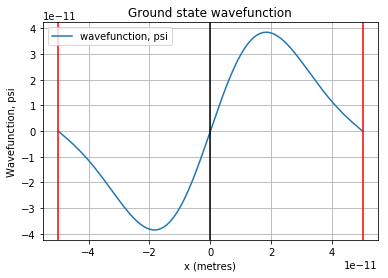

In [51]:
xplotpoints = np.arange(xstart, xend+h, h) #an array similar to xpoints, but this includes the end point

soln3 = RungeKutta2d(xpoints,E3) #the solution with the closest value to the roots

plt.grid()
plt.plot(xplotpoints, -soln3[0], label = "wavefunction, psi") #wavefunction
plt.axvline(x=0, c='k', ls='-') #y-axis


plt.legend(loc="best")
plt.title('Ground state wavefunction')
plt.xlabel('x (metres)')
plt.ylabel('Wavefunction, psi')
plt.legend(loc="best")

#plotting infinite walls at at +a and -a
plt.axvline(x=-a, c='r', ls='-') 
plt.axvline(x=+a, c='r', ls='-')

In [52]:
#coding for the trapezoidal rule:
I = h * ( (0.5*soln3[0,0])**2 + (0.5*soln3[0,1000])**2 + ((np.sum(soln3[0]**2) - soln3[0,0]**2 - soln3[0,1000]**2))  )

print ("the value of the integral =", I )

('the value of the integral =', 6.4012216025639637e-32)


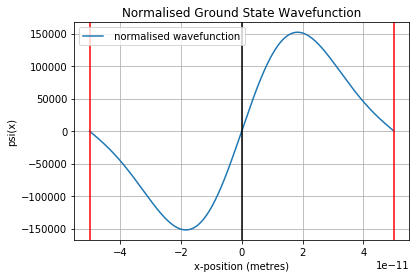

In [53]:
plt.plot(xplotpoints,(-soln3[0]/ np.sqrt(I)), label=" normalised wavefunction") #plots normalised wavefunction
plt.axvline(x=0,c='k',ls='-') 
plt.legend(loc="best") #place legend in best location
plt.grid(b=True, which='both', color='0.69',ls='-') #plot grey gridlines on the graph
plt.xlabel("x-position (metres)") 
plt.ylabel("psi(x)")
plt.title("Normalised Ground State Wavefunction") 

plt.axvline(x=-a,c='r', ls='-') 
plt.axvline(x=a,c='r',ls='-') 



In [54]:
def norm_function(x,n):
    '''a function which outputs the normalised values of the wavefunction, 
    input: n'''
    if n%2==0: #when the integer is divided by two, it uses the remainder to determine whether it is even or odd
        norm_values=((np.sin((n * np.pi * x)/(2.0*a)))/ (np.sqrt(a)) ) #when there is no remainder; it is even
    else: 
        norm_values=((np.cos((n * np.pi * x)/(2.0*a)))/ (np.sqrt(a)) ) #when there is a remainder; it is odd
        
    return norm_values

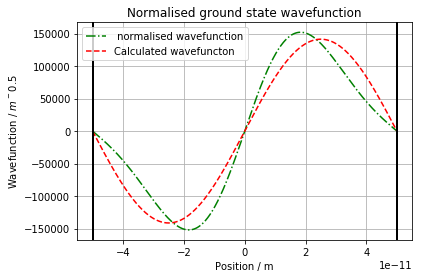

In [55]:
plt.grid()
plt.plot(xplotpoints, -(soln3[0]/ np.sqrt(I)), 'g-.', label=" normalised wavefunction") #plots normalised wavefunction
plt.plot(xplotpoints, norm_function(xplotpoints, level),'r--', label='Calculated wavefuncton') # plots known wavefunction for n=1
plt.xlabel('Position / m')
plt.ylabel('Wavefunction / $m^-0.5$')
plt.title('Normalised ground state wavefunction')
plt.legend(loc = 'best')

plt.axvline(x=-a, c='k', ls='-', lw=2)
plt.axvline(x=a, c='k', ls='-', lw=2)

#### a) n=3

Firstly, we need to calculate the energy for the second level, as this will allow us to make appropriate guesses for the secant method. Again, the equation used has been listed below:

$$
E_n = \frac{\pi^2 \hbar^2 n^2}{2m (2a)^2}
$$

In [56]:
#known energy for n=3
level=3
E_known = ((np.pi * hbar * level )**2) / (2*m*((2*a))**2)

print  ("The known ground state energy is", E_known/e," eV")

('The known ground state energy is', 338.4396935170008, ' eV')


In [57]:
E1 = 400*e          # guess 1 of initial E (J)
E2 = 590*e          # guess 2 of initial E (J)

####### Solve for the first guess:
soln1 = RungeKutta2d(xpoints, E1) # the whole array of solutions for E1
est1 = soln1[0,N]            # final element is at index N (counting from zero)

####### solve for the second guess:
soln2 = RungeKutta2d(xpoints, E2) # the whole array of solutions for E1
est2 = soln2[0,N]        # final element is at index N (counting from zero)

### now for the secant method to converge on the right answer
tolerance = e/1000 # set the tolerance
err = 1 # initialise the error variable
while err > tolerance:
    E3 = E2 - est2*(E2-E1)/(est2-est1)
    err = abs(E2-E1) 
    # reset initial energies for the next iteration
    E1 = E2 
    E2 = E3 
    # and recalculate heights
    soln1 = RungeKutta2d(xpoints, E1) # the whole array of solutions for E1
    soln2 = RungeKutta2d(xpoints, E2) # the whole array of solutions for E1

    est1 = soln1[0,N]
    est2 = soln2[0,N]
    
print("The ground state energy in an infinite square well is equal to", E3/e, "eV")

N3_energy = E3/e

('The ground state energy in an infinite square well is equal to', 580.4776744940616, 'eV')


The associated wavefunction has been calculated below:

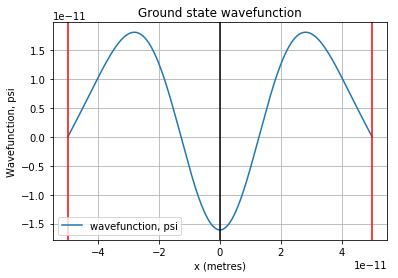

In [58]:
xplotpoints = np.arange(xstart, xend+h, h) #an array similar to xpoints, but this includes the end point

soln3 = RungeKutta2d(xpoints,E3) #the solution with the closest value to the roots

plt.grid()
plt.plot(xplotpoints, soln3[0], label = "wavefunction, psi") #wavefunction
plt.axvline(x=0, c='k', ls='-') #y-axis


plt.legend(loc="best")
plt.title('Ground state wavefunction')
plt.xlabel('x (metres)')
plt.ylabel('Wavefunction, psi')
plt.legend(loc="best")

#plotting infinite walls at at +a and -a
plt.axvline(x=-a, c='r', ls='-') 
plt.axvline(x=+a, c='r', ls='-')

In [59]:
#coding for the trapezoidal rule:
I = h * ( (0.5*soln3[0,0])**2 + (0.5*soln3[0,1000])**2 + ((np.sum(soln3[0]**2) - soln3[0,0]**2 - soln3[0,1000]**2))  )

print ("the value of the integral =", I )

('the value of the integral =', 1.4816450932693239e-32)


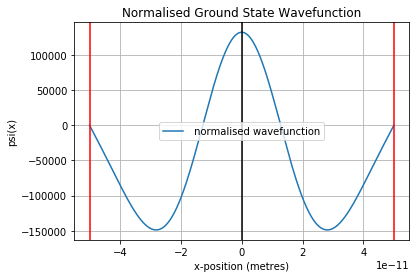

In [60]:
plt.plot(xplotpoints,-(soln3[0]/ np.sqrt(I)), label=" normalised wavefunction") #plots normalised wavefunction
plt.axvline(x=0,c='k',ls='-') 
plt.legend(loc="best") #place legend in best location
plt.grid(b=True, which='both', color='0.69',ls='-') #plot grey gridlines on the graph
plt.xlabel("x-position (metres)") 
plt.ylabel("psi(x)")
plt.title("Normalised Ground State Wavefunction") 

plt.axvline(x=-a,c='r', ls='-') 
plt.axvline(x=a,c='r',ls='-') 



In [61]:
def norm_function(x,n):
    '''a function which outputs the normalised values of the wavefunction, 
    input: n'''
    if n%2==0: #when the integer is divided by two, it uses the remainder to determine whether it is even or odd
        norm_values=((np.sin((n * np.pi * x)/(2.0*a)))/ (np.sqrt(a)) ) #when there is no remainder; it is even
    else: 
        norm_values=((np.cos((n * np.pi * x)/(2.0*a)))/ (np.sqrt(a)) ) #when there is a remainder; it is odd
        
    return norm_values

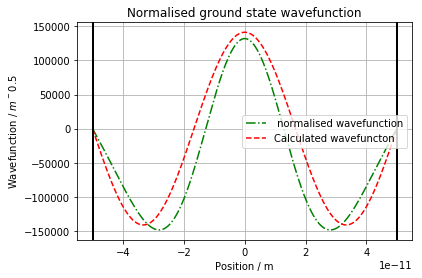

In [62]:
plt.grid()
plt.plot(xplotpoints, -(soln3[0]/ np.sqrt(I)), 'g-.', label=" normalised wavefunction") #plots normalised wavefunction
plt.plot(xplotpoints,norm_function(xplotpoints, level),'r--', label='Calculated wavefuncton') # plots known wavefunction for n=1
plt.xlabel('Position / m')
plt.ylabel('Wavefunction / $m^-0.5$')
plt.title('Normalised ground state wavefunction')
plt.legend(loc = 'best')

plt.axvline(x=-a, c='k', ls='-', lw=2)
plt.axvline(x=a, c='k', ls='-', lw=2)

#### a) n=4

Firstly, we need to calculate the energy for the second level, as this will allow us to make appropriate guesses for the secant method. Again, the equation used has been listed below:

$$
E_n = \frac{\pi^2 \hbar^2 n^2}{2m (2a)^2}
$$

In [63]:
#known energy for n=4
level=4
E2_known = ((np.pi * hbar * level )**2) / (2*m*((2*a))**2)

print  ("The known ground state energy is", E2_known/e," eV")

('The known ground state energy is', 601.670566252446, ' eV')


In [64]:
E1 = 750*e                        # guess 1 of initial E (J)
E2 = 900*e                     # guess 2 of initial E (J)

####### Solve for the first guess:
soln1 = RungeKutta2d(xpoints, E1) # the whole array of solutions for E1
est1 = soln1[0,N]            # final element is at index N (counting from zero)

####### solve for the second guess:
soln2 = RungeKutta2d(xpoints, E2) # the whole array of solutions for E1
est2 = soln2[0,N]        # final element is at index N (counting from zero)

### now for the secant method to converge on the right answer
tolerance = e/1000 # set the tolerance
err = 1 # initialise the error variable
while err > tolerance:
    E3 = E2 - est2*(E2-E1)/(est2-est1)
    err = abs(E2-E1) 
    # reset initial energies for the next iteration
    E1 = E2 
    E2 = E3 
    # and recalculate heights
    soln1 = RungeKutta2d(xpoints, E1) # the whole array of solutions for E1
    soln2 = RungeKutta2d(xpoints, E2) # the whole array of solutions for E1

    est1 = soln1[0,N]
    est2 = soln2[0,N]
    
print("The ground state energy in an infinite square well is equal to", E3/e, "eV")

N4_energy = E3/e

('The ground state energy in an infinite square well is equal to', 864.72836759082816, 'eV')


The associated wavefunction has been calculated below:

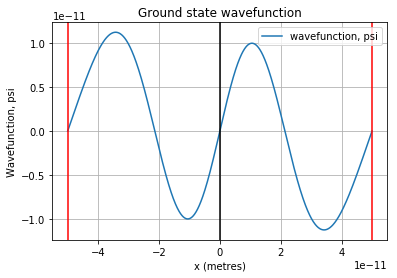

In [65]:
xplotpoints = np.arange(xstart, xend+h, h) #an array similar to xpoints, but this includes the end point

soln3 = RungeKutta2d(xpoints,E3) #the solution with the closest value to the roots

plt.grid()
plt.plot(xplotpoints, soln3[0], label = "wavefunction, psi") #wavefunction
plt.axvline(x=0, c='k', ls='-') #y-axis


plt.legend(loc="best")
plt.title('Ground state wavefunction')
plt.xlabel('x (metres)')
plt.ylabel('Wavefunction, psi')
plt.legend(loc="best")

#plotting infinite walls at at +a and -a
plt.axvline(x=-a, c='r', ls='-') 
plt.axvline(x=+a, c='r', ls='-')

In [66]:
#coding for the trapezoidal rule:
I = h * ( (0.5*soln3[0,0])**2 + (0.5*soln3[0,1000])**2 + ((np.sum(soln3[0]**2) - soln3[0,0]**2 - soln3[0,1000]**2))  )

print ("the value of the integral =", I )

('the value of the integral =', 5.6264680359202905e-33)


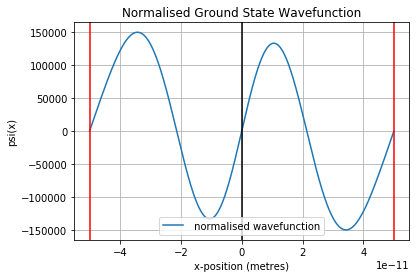

In [67]:
plt.plot(xplotpoints,(soln3[0]/ np.sqrt(I)), label=" normalised wavefunction") #plots normalised wavefunction
plt.axvline(x=0,c='k',ls='-') 
plt.legend(loc="best") #place legend in best location
plt.grid(b=True, which='both', color='0.69',ls='-') #plot grey gridlines on the graph
plt.xlabel("x-position (metres)") 
plt.ylabel("psi(x)")
plt.title("Normalised Ground State Wavefunction") 

plt.axvline(x=-a,c='r', ls='-') 
plt.axvline(x=a,c='r',ls='-') 



In [68]:
def norm_function(x,n):
    '''a function which outputs the normalised values of the wavefunction, 
    input: n'''
    if n%2==0: #when the integer is divided by two, it uses the remainder to determine whether it is even or odd
        norm_values=((np.sin((n * np.pi * x)/(2.0*a)))/ (np.sqrt(a)) ) #when there is no remainder; it is even
    else: 
        norm_values=((np.cos((n * np.pi * x)/(2.0*a)))/ (np.sqrt(a)) ) #when there is a remainder; it is odd
        
    return norm_values

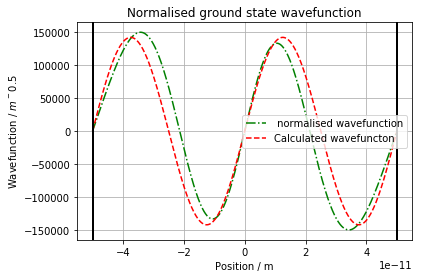

In [69]:
plt.grid()
plt.plot(xplotpoints, (soln3[0]/ np.sqrt(I)), 'g-.', label=" normalised wavefunction") #plots normalised wavefunction
plt.plot(xplotpoints,norm_function(xplotpoints, level),'r--', label='Calculated wavefuncton') # plots known wavefunction for n=1
plt.xlabel('Position / m')
plt.ylabel('Wavefunction / $m^-0.5$')
plt.title('Normalised ground state wavefunction')
plt.legend(loc = 'best')

plt.axvline(x=-a, c='k', ls='-', lw=2)
plt.axvline(x=a, c='k', ls='-', lw=2)

### 6. Finite 'Unsquare' Well

$$
V_x = \begin{cases} 0 & \text{if } -a/2 < x < +a/2, \\ 
    V_0  & \text{if } |x| > a/2, \end{cases} 
$$

In [70]:
def V(x): 
    '''the equation returns an output of 0 or V0 depending on the input position x
    output = 0 if -a/2 < x < +a/2
    output = V0 if |x| > a/2'''
    if (-a/2) < x < (a/2):
        return 0
    if abs(x) > (a/2):
        return V0
    

In [71]:
E1 = 0          # guess 1 of initial E (J)
E2 = 1000*e
soln1 = RungeKutta2d(xpoints, E1) # the whole array of solutions for E1
est1 = soln1[0,N]            # final element is at index N (counting from zero)

####### solve for the second guess:
soln2 = RungeKutta2d(xpoints, E2) # the whole array of solutions for E1
est2 = soln2[0,N]        # final element is at index N (counting from zero)

### now for the secant method to converge on the right answer
tolerance = e/1000 # set the tolerance
err = 1 # initialise the error variable
while err > tolerance:
    E3 = E2 - est2 * (E2-E1)/ (est2-est1)
    err = abs(E2-E1) 
    # reset initial energies for the next iteration
    E1 = E2 
    E2 = E3 
    # and recalculate heights
    soln1 = RungeKutta2d(xpoints, E1) # the whole array of solutions for E1
    soln2 = RungeKutta2d(xpoints, E2) # the whole array of solutions for E1

    est1 = soln1[0,N]
    est2 = soln2[0,N]
    
print("The ground state energy in an infinite square well is equal to", E3/e, "eV")

N4_energy = E3/e

('The ground state energy in an infinite square well is equal to', 1117.5520088089036, 'eV')


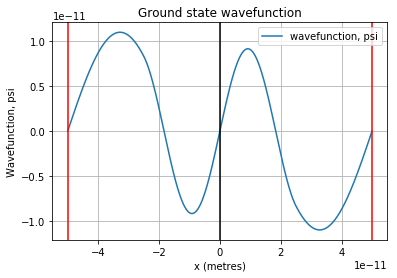

In [72]:
xplotpoints = np.arange(xstart, xend+h, h) #an array similar to xpoints, but this includes the end point

soln3 = RungeKutta2d(xpoints,E3) #the solution with the closest value to the roots

plt.grid()
plt.plot(xplotpoints, soln3[0], label = "wavefunction, psi") #wavefunction
plt.axvline(x=0, c='k', ls='-') #y-axis


plt.legend(loc="best")
plt.title('Ground state wavefunction')
plt.xlabel('x (metres)')
plt.ylabel('Wavefunction, psi')
plt.legend(loc="best")

#plotting infinite walls at at +a and -a
plt.axvline(x=-a, c='r', ls='-') 
plt.axvline(x=+a, c='r', ls='-')